In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import os

In [3]:
src_file = os.path.join('data', 'raw', 'EPA_fuel_economy.csv')
image_dir = ('images')

In [4]:
df = pd.read_csv(src_file)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data\\raw\\EPA_fuel_economy.csv'

In [ ]:
df.info()

In [ ]:
#Combined fuel consumption, both in the city and on the highway
n, bins, patches=plt.hist(df['comb08'],range=(10,50), bins=50)

In [ ]:
print(n)
print(bins)

In [ ]:
fig, ax = plt.subplots()
ax.hist(df['comb08'], range=(10,50), histtype='step', orientation='horizontal');
ax.set_xlabel('Number of cars')
ax.set_ylabel('Combined Fuel Economy (MPG)')
ax.set_title('Combined Fuel Economy ')


In [ ]:
fig, ax = plt.subplots(2)
ax[0].hist(df['comb08'], range=(10,50))
ax[1].hist(df['comb08'], range=(10,100));

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].boxplot(df['comb08'], labels=['All'], showfliers=False)
ax[0].set(title='MPG Distribution', ylabel='MPG for vehicles')
ax[1].boxplot(df['comb08'], labels=['All'])
ax[1].set(title='MPG Distribution', ylabel='MPG for vehicles');

In [ ]:
fig, (ax1, ax2) = plt.subplots(2)
ax1.hist(df['comb08'], range=(10,50))
ax1.set(title='Vehicle MPG', xlabel='Combined MPG', ylabel='Number of Cars')

ax2.boxplot(df['comb08'], labels=['All'], vert=False, showfliers=False)
ax2.set(ylabel='MPG for vehicles')

fig.suptitle('MPG Distribution', fontsize=14, fontweight='bold')
fig.savefig(os.path.join('image_dir', 'mpg.png'), transparent=True, dpi=80, bbox_inches="tight")

In [ ]:
avg_by_year = df.groupby(['year'], as_index=False).agg({'comb08': 'mean'}).round(2)
avg_by_year

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(avg_by_year['year'], avg_by_year['comb08'])
ax[0].set_xticks(np.arange(2000, 2022, 2))
ax[1].barh(avg_by_year['year'], avg_by_year['comb08']);

In [ ]:
fig, ax1 = plt.subplots(figsize=(9,7))
ax1.scatter(x=df['fuelCost08'], y=df['displ'], alpha=0.5, c=df['cylinders'])
ax1.set_xlabel('Cost', size=14)
ax1.set_ylabel('Displacement', size=14)
ax1.xaxis.set_major_formatter('${x:,.0f}')
ax1.tick_params(axis='x', labelrotation=45, labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.axvline(3500, color='black', linestyle=':')
ax1.annotate('Target of $3500', xy=(3500,2), size=16)
ax1.grid(True)

In [5]:
avg_by_year = df.groupby(['year']).agg({'highway08': 'mean', 
                          'city08': 'mean', 'comb08': 'mean'})
avg_by_year

NameError: name 'df' is not defined

In [6]:
avg_by_year.plot(kind='box',  title='Gas Mileage');

NameError: name 'avg_by_year' is not defined

In [7]:
avg_by_year.plot(kind='line', title='Gas Mileage', figsize=(9,5), 
                 xticks=np.arange(2000,2022,2), ylim=(0,32),
                 rot=45);

NameError: name 'avg_by_year' is not defined

In [8]:
avg_by_year.plot(kind='bar', rot=45, figsize=(10,5))

NameError: name 'avg_by_year' is not defined

In [9]:
avg_by_year.plot(kind='area')

NameError: name 'avg_by_year' is not defined

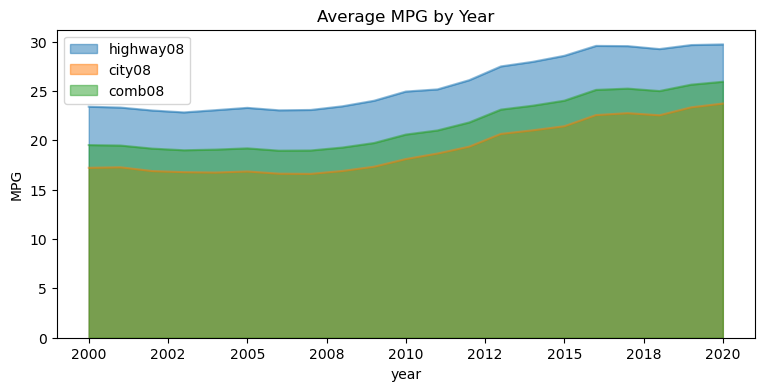

In [35]:
fig, ax1 = plt.subplots(figsize=(9, 4))
avg_by_year.plot(kind='area', ax=ax1, stacked=False)
ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:0.0f}"))
ax1.set(ylabel='MPG', title='Average MPG by Year');

<Axes: ylabel='Frequency'>

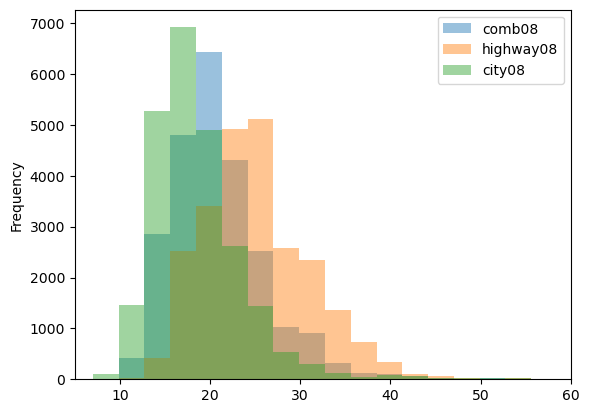

In [36]:
df[['comb08', 'highway08', 'city08']].plot(kind='hist', alpha=0.45, xlim=(5,60), bins=50)

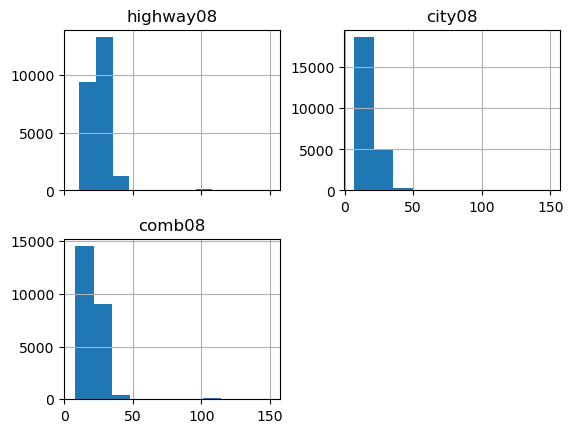

In [37]:
df.hist(column=['highway08', 'city08', 'comb08'], sharex=True);

In [38]:
df['fuelType'].value_counts()

fuelType
Regular                        12069
Premium                         9731
Gasoline or E85                 1339
Diesel                           338
Electricity                      231
Premium or E85                   127
Midgrade                         118
Premium and Electricity           75
Regular Gas and Electricity       52
Premium Gas or Electricity        51
CNG                               47
Gasoline or natural gas           20
Gasoline or propane                8
Regular Gas or Electricity         4
Name: count, dtype: int64

In [39]:
combustion = ['Regular', 'Premium', 'Gasoline or E85', 'Premium or E85', 'Midgrade']
combustion_df = df.query('fuelType == @combustion').copy()

In [40]:
combustion_df.head()

,make,model,year,cylinders,trany,displ,VClass,co2,barrels08,fuelCost08,fuelType,highway08,city08,comb08
0,Acura,NSX,2000,6.0,Automatic 4-spd,3.0,Two Seaters,-1,18.311667,2600,Premium,22,15,18
1,Acura,NSX,2000,6.0,Manual 6-spd,3.2,Two Seaters,-1,18.311667,2600,Premium,22,15,18
2,BMW,M Coupe,2000,6.0,Manual 5-spd,3.2,Two Seaters,-1,17.347895,2500,Premium,23,17,19
3,BMW,Z3 Coupe,2000,6.0,Automatic 4-spd,2.8,Two Seaters,-1,17.347895,2500,Premium,24,17,19
4,BMW,Z3 Coupe,2000,6.0,Manual 5-spd,2.8,Two Seaters,-1,17.347895,2500,Premium,24,17,19


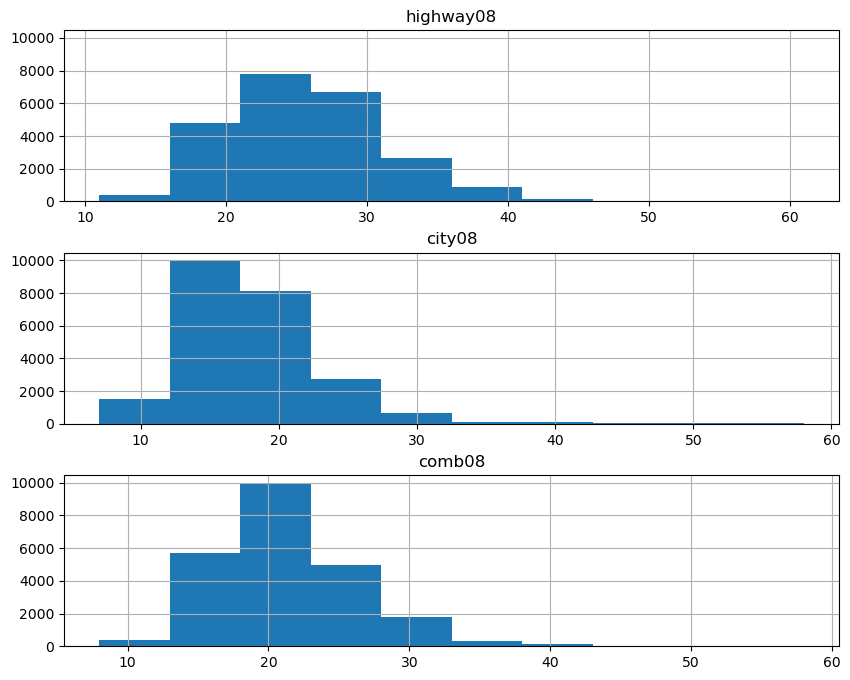

In [41]:
combustion_df.hist(column=['highway08','city08', 'comb08'], 
                   figsize=(10,8), sharey=True, 
                   layout=(3,1));

array([<Axes: title={'center': 'highway08'}, xlabel='cylinders'>,
       <Axes: title={'center': 'city08'}, xlabel='cylinders'>],
      dtype=object)

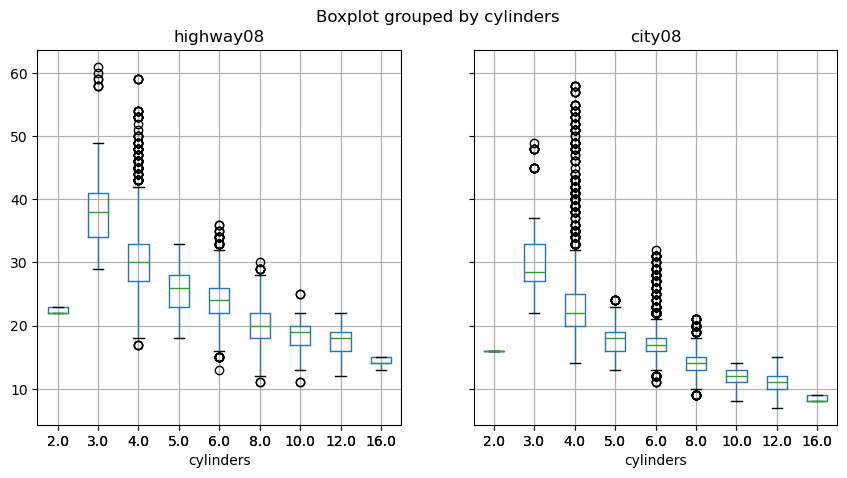

In [43]:
combustion_df.boxplot(column=['highway08', 'city08'], by='cylinders', figsize=(10,5))

In [1]:
data_summary = os.path.join('data', 'raw', 'EPA_fuel_economy_summary.csv')
df = pd.read_csv(data_summary)

NameError: name 'os' is not defined